# Lab 2 — Partner B: explain **one prediction** (local SHAP)

You own the **local** question: pick a single hour and explain **why the model predicted what it did**
for *that* hour - the kind of answer you'd give a stakeholder who asks "why is your number so high?"

Your night:
1. Run the setup + SHAP setup (given)
2. Check how good the model is with a **predicted-vs-actual** plot (given)
3. **Write one line** to make a **SHAP waterfall** for the peak-demand hour (your only coding task)
4. Ship the two PNGs + this notebook through a pull request on branch `dev-local`

> Type the one SHAP line yourself.

In [3]:
# --- setup: install SHAP, load the data, fit the model (just run this) ---
!pip install shap -q

import pandas as pd, numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

url = "https://raw.githubusercontent.com/drdave-teaching/opim5512-lab2-template/main/data/energy_model_data.csv"
df = pd.read_csv(url, parse_dates=["hour"]).sort_values("hour").reset_index(drop=True)  # keep time in order

FEATURES = ["temp_f", "hour_of_day", "dewpoint_f", "humidity_pct", "wind_kt", "weekend"]
X, y = df[FEATURES], df["load_mw"]

# TIME SERIES -> no shuffle: the test set is the most recent 20% of hours (a real forecast, no peeking ahead)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, shuffle=False)
model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr)
print(f"model R2 (test): {r2_score(yte, model.predict(Xte)):.2f}   |   typical miss: {mean_absolute_error(yte, model.predict(Xte)):,.0f} MW")
X.head()

model R2 (test): 0.83   |   typical miss: 662 MW


,temp_f,hour_of_day,dewpoint_f,humidity_pct,wind_kt,weekend
0,65.0,0,51.0,60.49,5.0,0
1,60.0,1,51.0,72.13,4.0,0
2,60.0,2,51.0,72.13,0.0,0
3,55.0,3,51.0,86.35,0.0,0
4,57.0,4,53.0,86.46,4.0,0


### Deploy it: save the model, then load it back (just run this)

In production you don't retrain every time - you **ship** the trained model as a file and **load** it to serve predictions. Same idea here: we save the forest to `energy_rf.joblib`, then load it back and use the *loaded* copy for the rest of the lab (SHAP works on it exactly the same).

In [4]:
import joblib
joblib.dump(model, "energy_rf.joblib")     # the trained model as a shippable artifact
model = joblib.load("energy_rf.joblib")    # ...load it back, as if you were serving it
print("loaded energy_rf.joblib -> test-set predictions:", model.predict(Xte.iloc[:3]).round().tolist(), "MW")

loaded energy_rf.joblib -> test-set predictions: [18729.0, 17631.0, 17496.0] MW


### How the model was built (read this — don't code it tonight)

We reused the joined weather + demand data **you built in Lab 1** — one row per hour — and trained a
small **random forest** to predict New England electricity demand from six features. It's accurate
(R² ≈ 0.83 on a held-out, time-ordered test set — a tougher, more honest test than a shuffled split), which makes it worth asking the real question of Module 2: **how does it decide?**

| feature | meaning | units |
|---|---|---|
| `temp_f` | air temperature | deg F |
| `hour_of_day` | 0-23, the hour the reading begins | hour |
| `dewpoint_f` | dew point (muggy-ness) | deg F |
| `humidity_pct` | relative humidity | % |
| `wind_kt` | wind speed | knots |
| `weekend` | 1 on Sat/Sun, else 0 | 0/1 |

**SHAP** answers "how did the model decide" by giving every feature, for every prediction, a number
in **MW**: how much it pushed that prediction **up (+)** or **down (-)** from the average. Add them
all up and you get the model's prediction. That's the whole idea.

In [5]:
# --- SHAP setup (just run this): explain the model on the HELD-OUT test hours ---
explainer = shap.TreeExplainer(model)
shap_values = explainer(Xte)        # explain UNSEEN data (honest) - one row per test hour, one column per feature
print("SHAP ready:", shap_values.shape, "(test hours x features)")

SHAP ready: (149, 6) (test hours x features)


## 1. Is the model any good? (given) predicted vs actual

Run this - it saves `predicted_vs_actual.png`. Points on the diagonal = perfect predictions.

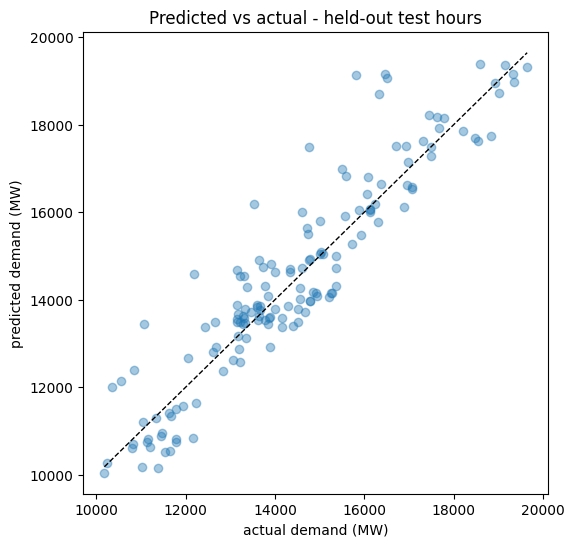

saved predicted_vs_actual.png


In [6]:
pred = model.predict(Xte)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(yte, pred, alpha=0.4)
lims=[yte.min(), yte.max()]; ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("actual demand (MW)"); ax.set_ylabel("predicted demand (MW)")
ax.set_title("Predicted vs actual - held-out test hours")
fig.savefig("predicted_vs_actual.png", dpi=150, bbox_inches="tight")  # save first (never blank)
plt.show()                                                             # then look at it
print("saved predicted_vs_actual.png")

## 2. Your turn: a SHAP waterfall for the peak hour (one line)

The busiest hour in the **test set** is the one to explain. This finds it for you:

```
i = int(np.argmax(model.predict(Xte)))             # position of the highest-demand TEST hour
h = Xte.index[i]                                    # its row back in df
print("explaining:", df.loc[h, "hour"], "| actual:", round(df.loc[h, "load_mw"]), "MW")
```

Now **view** the waterfall for that hour, **then save** it:

```
shap.plots.waterfall(shap_values[i])               # 1) LOOK at it in the notebook
shap.plots.waterfall(shap_values[i], show=False)   # 2) then save a copy for the report
plt.gcf().savefig("shap_local.png", dpi=150, bbox_inches="tight"); plt.close()
```

Then read it: which features pushed this prediction **up** (red) and which pulled it **down**
(blue)? Is it mostly the hour of day, the weather, or both? That sentence is your finding.

In [7]:
# TODO: find the peak hour (i), print it, then make the waterfall -> shap_local.png



### Download both PNGs to your laptop

In [8]:
import os
from google.colab import files
for p in ['predicted_vs_actual.png', 'shap_local.png']:
    if os.path.exists(p):
        files.download(p)
    else:
        print(f"{p} not found yet - run the cell that makes it, then re-run this one.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

shap_local.png not found yet - run the cell that makes it, then re-run this one.


## Ship it (this is the git half of the lab)

1. **This notebook -> GitHub:** **File -> Save** -> your repo, branch **`dev-local`**, keep the path
   `notebooks/Lab2_B_Local_SHAP.ipynb`, real commit message. (Plain **Save** commits to GitHub because you opened it
   *from* GitHub. Ctrl+S only autosaves to Drive.)
2. **The two PNGs -> your repo:** the download cell put them in your Downloads folder. GitHub Desktop
   -> **Repository -> Show in Explorer** -> drag `predicted_vs_actual.png` and `shap_local.png` into **`images/`**
   (rename any `(1)` copy back first).
3. GitHub Desktop: on branch **`dev-local`** -> **Commit** (real message) -> **Push** ->
   github.com **Compare & pull request** -> ask your partner to review.